In [1]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence
from typing import Literal

In [2]:
def setup_environment():
    import sys
    sys.path.append('C:\\gitworkspace\\aimldemo\\jupyterworkapce')
    import stratup_env_setup
    stratup_env_setup.set_env()

In [3]:
setup_environment()

# Define the State

In [4]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [5]:
state = State(messages = [HumanMessage("Could you tell me a grook by Piet Hein?")])

In [6]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me a grook by Piet Hein?


# Define the Nodes

In [7]:
chat = ChatOpenAI(model = "gpt-4o", 
                  seed = 365, 
                  temperature = 0, 
                  max_completion_tokens = 100)

In [8]:
response = chat.invoke(state["messages"])

In [9]:
response.pretty_print()

================================== Ai Message ==================================

Certainly! Here's a well-known grook by Piet Hein:

```plaintext
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are known for their brevity and wit, often conveying deep insights in just a few lines.


In [10]:
def chatbot(state: State) -> State:
    
    print(f"\n-------> ENTERING chatbot:")
    
    response = chat.invoke(state["messages"])
    response.pretty_print()
    
    return State(messages = [response])

In [11]:
chatbot(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! Here is one of Piet Hein's well-known grooks:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are short, witty poems that often contain philosophical insights or reflections on everyday life.


{'messages': [AIMessage(content="Certainly! Here is one of Piet Hein's well-known grooks:\n\n```\nLosing One Glove\n\nLosing one glove\nis certainly painful,\nbut nothing\ncompared to the pain\nof losing one,\nthrowing away the other,\nand finding\nthe first one again.\n```\n\nPiet Hein's grooks are short, witty poems that often contain philosophical insights or reflections on everyday life.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 18, 'total_tokens': 100, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fb0b7b429c', 'id': 'chatcmpl-DNKNS594PzORPKp5T425MhwvPxQW4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d2598-83ac-7d90-ac19-5

# Define the Graph

In [12]:
graph = StateGraph(State)

In [13]:
graph.add_node("chatbot", chatbot)

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [14]:
graph_compiled = graph.compile()

In [15]:
isinstance(graph, Runnable)

False

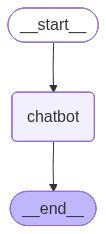

In [16]:
graph_compiled

# Test the Graph

In [17]:
graph_compiled.invoke(state)


-------> ENTERING chatbot:
================================== Ai Message ==================================

Certainly! Here's a well-known grook by Piet Hein:

```
Losing One Glove

Losing one glove
is certainly painful,
but nothing
compared to the pain
of losing one,
throwing away the other,
and finding
the first one again.
```

Piet Hein's grooks are known for their brevity and wit, often conveying deep insights in just a few lines.


{'messages': [AIMessage(content="Certainly! Here's a well-known grook by Piet Hein:\n\n```\nLosing One Glove\n\nLosing one glove\nis certainly painful,\nbut nothing\ncompared to the pain\nof losing one,\nthrowing away the other,\nand finding\nthe first one again.\n```\n\nPiet Hein's grooks are known for their brevity and wit, often conveying deep insights in just a few lines.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 18, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_fb0b7b429c', 'id': 'chatcmpl-DNKOG5tB2HgVZ3GDAIiazLVXyw6io', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d2599-4614-7452-b33b-73fcd66eae12-0', 

# Conditional Nodes

In [18]:
def ask_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_question:")
    
    print("What is your question?")
    
    return State(messages = [HumanMessage(input())])

In [19]:
ask_question(State(messages = []))


-------> ENTERING ask_question:
What is your question?
hi


{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={})]}

In [20]:
def ask_another_question(state: State) -> State:
    
    print(f"\n-------> ENTERING ask_another_question:")
    
    print("Would you like to ask one more question (yes/no)?")
    
    return State(messages = [HumanMessage(input())])

In [21]:
ask_another_question(State(messages = []))


-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?
hello


{'messages': [HumanMessage(content='hello', additional_kwargs={}, response_metadata={})]}

In [22]:
def routing_function(state: State) -> Literal["ask_question", "__end__"]:
    
    if state["messages"][0].content == "yes":
        return "ask_question"
    else:
        return "__end__"

In [23]:
graph = StateGraph(State)

In [24]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)

In [25]:
graph_compiled = graph.compile()

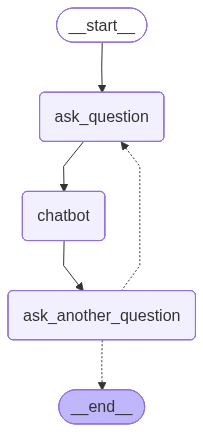

In [26]:
graph_compiled

In [27]:
graph_compiled.invoke(State(messages = []))


-------> ENTERING ask_question:
What is your question?
hi

-------> ENTERING chatbot:
================================== Ai Message ==================================

Hello! How can I assist you today?

-------> ENTERING ask_another_question:
Would you like to ask one more question (yes/no)?
no


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}